## 🌡️ Climate Change Analysis & Temperature Prediction

### 📂 Dataset
- **Source:** [Kaggle — Climate Change: Earth Surface Temperature Data](https://www.kaggle.com/datasets/berkeleyearth/climate-change-earth-surface-temperature-data)
- **File used:** `GlobalTemperatures.csv`
- **Records:** 3,192 entries spanning over 250 years

### 🛠️ Tools & Libraries
- Python, Pandas, Matplotlib, Seaborn, Scikit-learn

---

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style='darkgrid')

In [2]:
climate_data = pd.read_csv('../data/GlobalTemperatures.csv')

In [3]:
climate_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 3192 entries, 0 to 3191
Data columns (total 9 columns):
 #   Column                                     Non-Null Count  Dtype  
---  ------                                     --------------  -----  
 0   dt                                         3192 non-null   str    
 1   LandAverageTemperature                     3180 non-null   float64
 2   LandAverageTemperatureUncertainty          3180 non-null   float64
 3   LandMaxTemperature                         1992 non-null   float64
 4   LandMaxTemperatureUncertainty              1992 non-null   float64
 5   LandMinTemperature                         1992 non-null   float64
 6   LandMinTemperatureUncertainty              1992 non-null   float64
 7   LandAndOceanAverageTemperature             1992 non-null   float64
 8   LandAndOceanAverageTemperatureUncertainty  1992 non-null   float64
dtypes: float64(8), str(1)
memory usage: 224.6 KB


In [4]:
climate_data.describe()

,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty
count,3180.000000,3180.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000,1992.000000
mean,8.374731,0.938468,14.350601,0.479782,2.743595,0.431849,15.212566,0.128532
std,4.381310,1.096440,4.309579,0.583203,4.155835,0.445838,1.274093,0.073587
min,-2.080000,0.034000,5.900000,0.044000,-5.407000,0.045000,12.475000,0.042000
25%,4.312000,0.186750,10.212000,0.142000,-1.334500,0.155000,14.047000,0.063000
50%,8.610500,0.392000,14.760000,0.252000,2.949500,0.279000,15.251000,0.122000
75%,12.548250,1.419250,18.451500,0.539000,6.778750,0.458250,16.396250,0.151000
max,19.021000,7.880000,21.320000,4.373000,9.715000,3.498000,17.611000,0.457000


## 🧹 Data Preprocessing
> Before analysis, we prepare the dataset by fixing data types and handling missing values.

Steps:
- Convert `dt` column from string to datetime format
- Extract `year` from datetime for time series analysis
- Handle missing values

In [5]:
climate_data['dt'] = pd.to_datetime(climate_data['dt'])
climate_data.dtypes

dt                                           datetime64[us]
LandAverageTemperature                              float64
LandAverageTemperatureUncertainty                   float64
LandMaxTemperature                                  float64
LandMaxTemperatureUncertainty                       float64
LandMinTemperature                                  float64
LandMinTemperatureUncertainty                       float64
LandAndOceanAverageTemperature                      float64
LandAndOceanAverageTemperatureUncertainty           float64
dtype: object

In [6]:
climate_data['year'] = climate_data['dt'].dt.year
climate_data.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty,year
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN,1750
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN,1750
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN,1750
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN,1750
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN,1750


In [7]:
climate_data.isnull().sum()

dt                                              0
LandAverageTemperature                         12
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
year                                            0
dtype: int64

## 📝 Handling Missing Values — Two Methods

### Method 1 — Drop missing rows
Use when: missing values are less than 1-2% of data and data is NOT time series
```python
climate_data = climate_data.dropna(subset=['LandAverageTemperature'])
```

### Method 2 — Fill with mean (Imputation)
Use when: data is time series OR missing values are large % of total data
```python
climate_data['LandAverageTemperature'] = climate_data['LandAverageTemperature'].fillna(climate_data['LandAverageTemperature'].mean())
```
### 📌 When to use which?
| Situation | Method |
|-----------|--------|
| Missing < 1-2% of data | Drop |
| Missing > 1-2% of data | Fill with mean |
| Time series data | Always Fill |
| Random/non-time data | Drop is safer |

In [8]:
climate_data['LandAverageTemperature'] = climate_data['LandAverageTemperature'].fillna(climate_data['LandAverageTemperature'].mean())
climate_data.isnull().sum()

dt                                              0
LandAverageTemperature                          0
LandAverageTemperatureUncertainty              12
LandMaxTemperature                           1200
LandMaxTemperatureUncertainty                1200
LandMinTemperature                           1200
LandMinTemperatureUncertainty                1200
LandAndOceanAverageTemperature               1200
LandAndOceanAverageTemperatureUncertainty    1200
year                                            0
dtype: int64

## 📊 Analysis 1: Global Temperature Trend Over Time
> How has the global average land temperature changed over the centuries?

We group the data by year and calculate the average land temperature 
for each year to visualize the long-term temperature trend from the 
1700s to 2015.

**Expected Finding:** Based on climate science, we expect to see a 
gradual rise in temperatures — especially after the Industrial Revolution 
in the mid-1800s.

In [9]:
yearly_temp = climate_data.groupby('year')['LandAverageTemperature'].mean()
print(yearly_temp)

year
1750    8.690644
1751    8.142221
1752    7.077282
1753    8.388083
1754    8.469333
          ...   
2011    9.516000
2012    9.507333
2013    9.606500
2014    9.570667
2015    9.831000
Name: LandAverageTemperature, Length: 266, dtype: float64


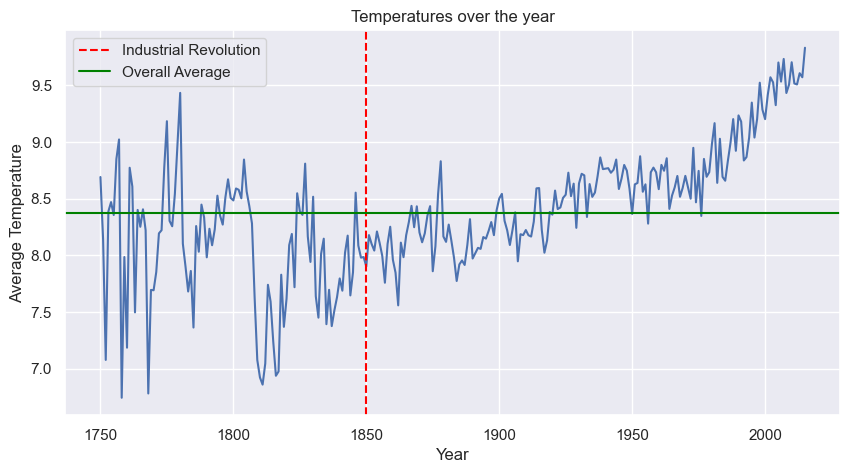

In [10]:
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_temp.index, y=yearly_temp.values)
plt.axvline(x=1850, color='red', linestyle='--', label='Industrial Revolution')
plt.axhline(y=yearly_temp.mean(), color='green', linestyle='-', label='Overall Average')
plt.title('Temperatures over the year')
plt.xlabel('Year')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

## 💡 Insight — Global Temperature Trend Over Time

Analyzing global average land temperatures from the **1700s to 2015** 
reveals a clear and concerning warming trend.

- 🌡️ Temperatures remained **relatively stable** from 1750 to 1850
- 🏭 After **1850** — coinciding with the **Industrial Revolution** — 
temperatures began rising gradually as fossil fuel consumption increased
- 🔥 The rise becomes **significantly steeper after 1950** — reflecting 
accelerated industrialization and increased CO2 emissions globally
- 📈 Overall, global average land temperature has risen by approximately 
**1.5°C** over the entire recorded period

**💡 Key Takeaway:** The data clearly confirms the impact of human 
industrial activity on global temperatures. The warming trend accelerating 
post-1850 is not a coincidence — it directly mirrors the rise of 
fossil fuel consumption across the world.

## 🌡️ Analysis 2: Temperature Fluctuation Over The Years
> How has the gap between maximum and minimum land temperatures changed over time?

We analyze the `LandMaxTemperature` and `LandMinTemperature` columns to understand:
- How wide is the temperature range each year?
- Has the gap between max and min temperatures changed over time?
- Are extreme temperatures becoming more frequent?

In [11]:
temp_fluctuation = climate_data.groupby('year').agg(
    max_temp =('LandMaxTemperature','max'),
    min_temp =('LandMinTemperature','min')
)
print(temp_fluctuation)

      max_temp  min_temp
year                    
1750       NaN       NaN
1751       NaN       NaN
1752       NaN       NaN
1753       NaN       NaN
1754       NaN       NaN
...        ...       ...
2011    21.320    -2.034
2012    21.006    -2.233
2013    20.737    -1.726
2014    20.790    -2.080
2015    20.904    -1.518

[266 rows x 2 columns]


In [12]:
temp_fluctuation = temp_fluctuation.dropna()
print(temp_fluctuation)

      max_temp  min_temp
year                    
1850    19.233    -3.206
1851    17.361    -3.242
1852    17.795    -2.755
1853    19.308    -4.015
1854    20.426    -4.109
...        ...       ...
2011    21.320    -2.034
2012    21.006    -2.233
2013    20.737    -1.726
2014    20.790    -2.080
2015    20.904    -1.518

[166 rows x 2 columns]


In [13]:
temp_fluctuation['temp_range']= temp_fluctuation['max_temp']- temp_fluctuation['min_temp']
print(temp_fluctuation)

      max_temp  min_temp  temp_range
year                                
1850    19.233    -3.206      22.439
1851    17.361    -3.242      20.603
1852    17.795    -2.755      20.550
1853    19.308    -4.015      23.323
1854    20.426    -4.109      24.535
...        ...       ...         ...
2011    21.320    -2.034      23.354
2012    21.006    -2.233      23.239
2013    20.737    -1.726      22.463
2014    20.790    -2.080      22.870
2015    20.904    -1.518      22.422

[166 rows x 3 columns]


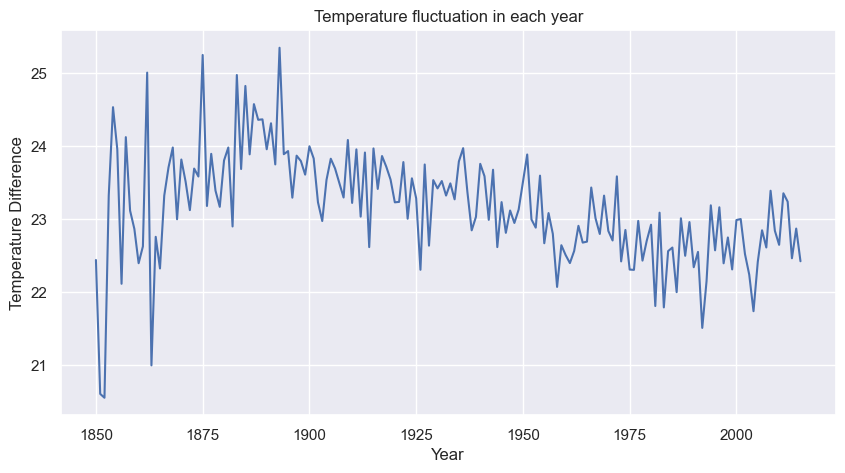

In [14]:
plt.figure(figsize=(10,5))
sns.lineplot(x=temp_fluctuation.index, y=temp_fluctuation['temp_range'].values)
plt.title('Temperature fluctuation in each year')
plt.xlabel('Year')
plt.ylabel('Temperature Difference')
plt.show()

## 💡 Insight — Temperature Fluctuation Over The Years

Analyzing the gap between maximum and minimum land temperatures 
from **1850 to 2015** reveals an interesting pattern.

- 🌡️ Data for Max and Min temperatures is only available from **1850** 
onwards — coinciding with the start of the Industrial Revolution
- 📉 From around **1900s onwards**, the gap between max and min 
temperatures shows a **slight declining trend**
- ❄️ This suggests that **minimum temperatures are rising faster** 
than maximum temperatures — winters are getting warmer
- 🔥 This is consistent with global climate science — cold extremes 
are warming faster than hot extremes due to greenhouse gas emissions

**💡 Key Takeaway:** The narrowing temperature range is a subtle but 
important indicator of climate change — the world is not just getting 
hotter on average, the nature of temperature extremes is changing too.

## 🌊 Analysis 3: Land vs Ocean Temperature Comparison
> How do land and ocean average temperatures compare over time?

We compare `LandAverageTemperature` and `LandAndOceanAverageTemperature` 
to understand:
- Is there a consistent difference between land and ocean temperatures?
- Are land and ocean warming at the same rate?
- Which one is warming faster?

In [15]:
landOcean_temp = climate_data.groupby('year')['LandAndOceanAverageTemperature'].mean()
print(landOcean_temp)

year
1750          NaN
1751          NaN
1752          NaN
1753          NaN
1754          NaN
          ...    
2011    15.769500
2012    15.802333
2013    15.854417
2014    15.913000
2015    16.058583
Name: LandAndOceanAverageTemperature, Length: 266, dtype: float64


In [16]:
landOcean_temp=landOcean_temp.dropna()
print(landOcean_temp)

year
1850    14.867167
1851    14.991833
1852    15.006500
1853    14.955167
1854    14.991000
          ...    
2011    15.769500
2012    15.802333
2013    15.854417
2014    15.913000
2015    16.058583
Name: LandAndOceanAverageTemperature, Length: 166, dtype: float64


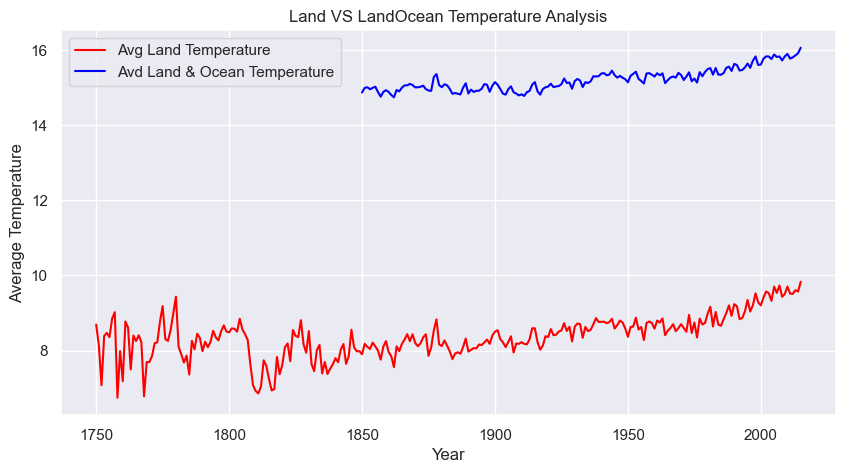

In [17]:
plt.figure(figsize=(10,5))
sns.lineplot(x=yearly_temp.index, y=yearly_temp.values, label='Avg Land Temperature', color='red')
sns.lineplot(x=landOcean_temp.index, y=landOcean_temp.values, label='Avd Land & Ocean Temperature', color='blue')
plt.title('Land VS LandOcean Temperature Analysis')
plt.xlabel('Year')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()

## 📅 Analysis 4: Monthly Seasonality
> Which months are the hottest and coldest globally throughout history?

We analyze the `dt` column to extract months and understand:
- Which months have the highest average temperatures?
- Which months are the coldest?
- Does the seasonal pattern remain consistent over the years?

In [18]:
climate_data['month'] = climate_data['dt'].dt.month
climate_data.head()

,dt,LandAverageTemperature,LandAverageTemperatureUncertainty,LandMaxTemperature,LandMaxTemperatureUncertainty,LandMinTemperature,LandMinTemperatureUncertainty,LandAndOceanAverageTemperature,LandAndOceanAverageTemperatureUncertainty,year,month
0,1750-01-01,3.034,3.574,NaN,NaN,NaN,NaN,NaN,NaN,1750,1
1,1750-02-01,3.083,3.702,NaN,NaN,NaN,NaN,NaN,NaN,1750,2
2,1750-03-01,5.626,3.076,NaN,NaN,NaN,NaN,NaN,NaN,1750,3
3,1750-04-01,8.490,2.451,NaN,NaN,NaN,NaN,NaN,NaN,1750,4
4,1750-05-01,11.573,2.072,NaN,NaN,NaN,NaN,NaN,NaN,1750,5


In [38]:
monthly_temp = climate_data.groupby('month')['LandAverageTemperature'].mean()
print(monthly_temp)

month
1      2.275211
2      2.981871
3      4.956872
4      8.248688
5     11.132163
6     13.324736
7     14.263175
8     13.739819
9     11.710582
10     8.883025
11     5.762197
12     3.218435
Name: LandAverageTemperature, dtype: float64


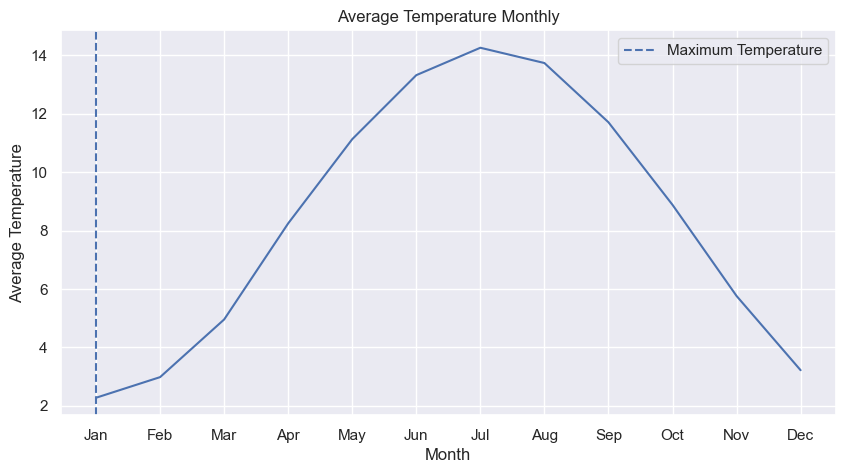

In [41]:
months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
plt.figure(figsize=(10,5))
sns.lineplot(x=months, y=monthly_temp.values)
plt.axvline(x=months[monthly_temp.values.argmin()], label='Maximum Temperature', linestyle='--')
plt.title('Average Temperature Monthly')
plt.xlabel('Month')
plt.ylabel('Average Temperature')
plt.legend()
plt.show()